# Construction Management 관점의 BIM 데이터 분석

건설 관리자(CM)가 이 데이터를 받았을 때 묻는 질문:

1. **어디에 무거운 것이 있는가?** — 양중(crane lift) 계획의 출발점
2. **시공 존을 어떻게 나눌 것인가?** — work packaging 의 기초
3. **어떤 파이프라인이 여러 존에 걸치는가?** — 시공 순서 제약의 핵심
4. **존 안에서 뭘 먼저 설치하는가?** — Equipment → Structure → Piping 순서

이 노트북은 질문 2에 대한 **A/B 테스트**를 실행합니다:
- **A: 공간 격자(15m grid)** — 물리적 근접성으로 존 정의
- **B: 그래프 커뮤니티(Louvain)** — adjacency 연결성으로 존 정의

어떤 방법이 "더 좋은 시공 존"을 만드는지를 구체적 지표로 비교합니다.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from collections import Counter

from bimkg import config

sns.set_theme(style="whitegrid", font_scale=1.1)

gold = pd.read_parquet(config.ENRICHED_OBJECTS)
adj = pd.read_parquet(config.ENRICHED_ADJACENCY_SYM)

# Physical objects only (exclude containers and analysis volumes)
phys = gold[(gold["is_container"] == False) & (gold["is_analysis_volume"] == False)].copy()
print(f"Physical objects: {len(phys):,} (containers {gold['is_container'].sum():,} + analysis {gold['is_analysis_volume'].sum()} excluded)")
print(f"Adjacency edges: {len(adj):,}")

Physical objects: 8,511 (containers 3,353 + analysis 145 excluded)
Adjacency edges: 220,346


## 1. 양중 지도 — 어디에 무거운 것이 있는가?

건설 현장에서 가장 먼저 결정하는 건 크레인 위치입니다. 무거운 객체가 어디에 몰려있는지, 클래스별로 무게 분포가 어떤지를 봅니다.

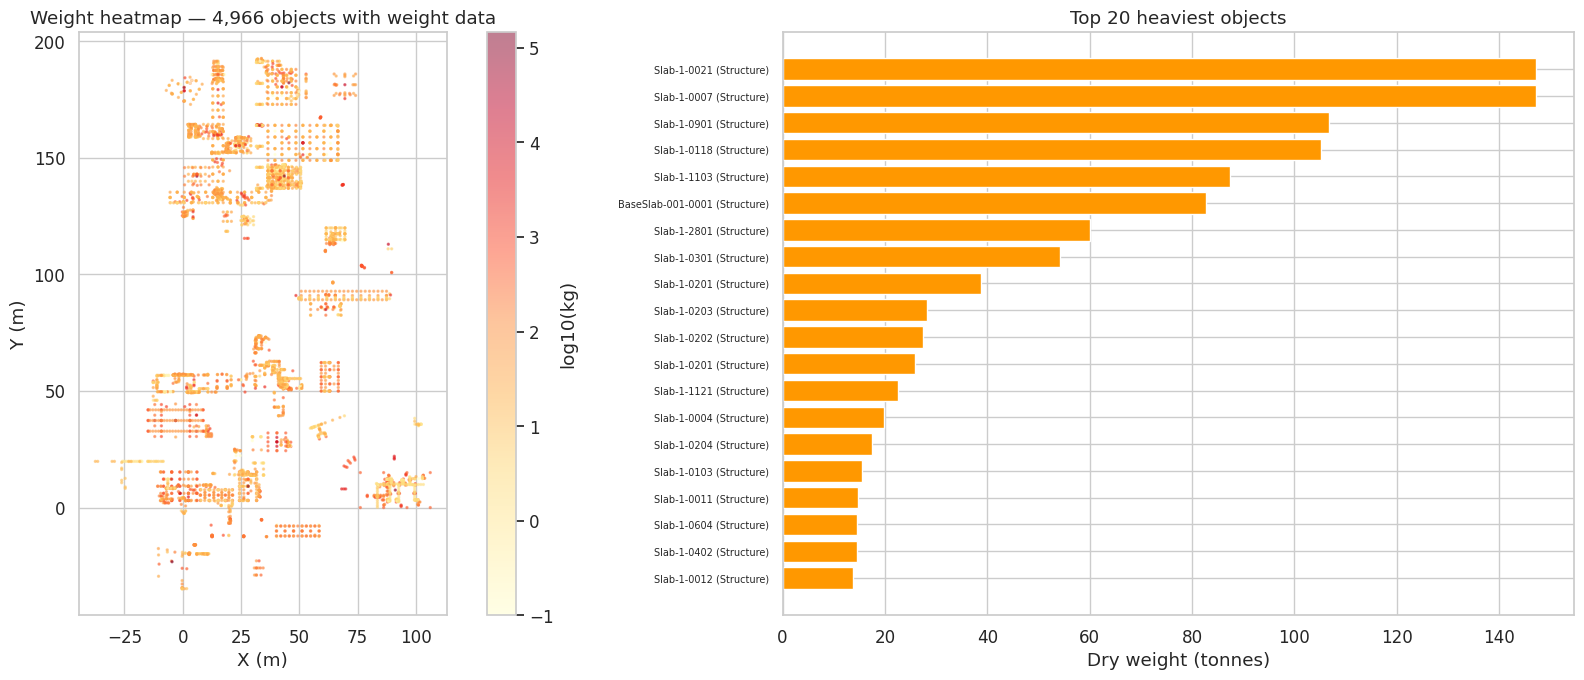

Total weight by class (tonnes):
  Structure      :    1,330.3 t
  Piping         :      169.5 t
  Other          :      122.8 t
  Electrical     :       42.3 t
  Equipment      :       41.2 t
  HVAC           :        9.1 t
  TOTAL          :    1,715.3 t


In [2]:
heavy = phys[phys["dry_weight_kg"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: weight heatmap (top view, binned)
ax = axes[0]
sc = ax.scatter(heavy["centroid_x"], heavy["centroid_y"],
                c=np.log10(heavy["dry_weight_kg"].clip(lower=0.1)),
                s=2, alpha=0.5, cmap="YlOrRd")
plt.colorbar(sc, ax=ax, label="log10(kg)")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title(f"Weight heatmap — {len(heavy):,} objects with weight data")
ax.set_aspect("equal")

# Right: top 20 heaviest objects
top20_heavy = heavy.nlargest(20, "dry_weight_kg")
labels = [f"{row.display_name[:30]} ({row.refined_class})" if pd.notna(row.display_name) 
          else f"{row.object_id[:12]}..." for _, row in top20_heavy.iterrows()]
colors = {"Piping": "#2196F3", "Structure": "#FF9800", "Equipment": "#4CAF50",
          "Electrical": "#F44336", "HVAC": "#9C27B0", "Other": "#9E9E9E"}
bar_colors = [colors.get(row.refined_class, "#999") for _, row in top20_heavy.iterrows()]
axes[1].barh(range(len(top20_heavy)), top20_heavy["dry_weight_kg"] / 1000, color=bar_colors)
axes[1].set_yticks(range(len(top20_heavy)))
axes[1].set_yticklabels(labels, fontsize=7)
axes[1].set_xlabel("Dry weight (tonnes)")
axes[1].set_title("Top 20 heaviest objects")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Summary by class
print("Total weight by class (tonnes):")
class_weight = heavy.groupby("refined_class")["dry_weight_kg"].sum().sort_values(ascending=False) / 1000
for cls, w in class_weight.items():
    print(f"  {cls:15s}: {w:10,.1f} t")
print(f"  {'TOTAL':15s}: {class_weight.sum():10,.1f} t")

## 2. A/B 테스트 — 시공 존 정의

건설 관리의 핵심 결정: **플랜트를 어떤 단위로 쪼개서 시공할 것인가?**

좋은 시공 존의 조건:
- 존 안의 객체들은 서로 **가까이** 있어야 한다 (자재 이동 최소화)
- 존 안의 객체들은 서로 **연결**되어 있어야 한다 (작업 연속성)
- 존 간 **교차 간선**이 적어야 한다 (존 간 의존성 = 시공 순서 제약)
- 존 크기가 **균일**해야 한다 (작업 패키지 밸런싱)

### 방법 A: 공간 격자 (15m grid)
XY 평면을 15m × 15m 격자로 나누고, 같은 셀에 있는 물체를 하나의 존으로 묶습니다.
장점: 직관적, 크레인 반경과 매핑 가능. 단점: 연결성을 무시.

### 방법 B: 그래프 커뮤니티 (Louvain)
adjacency 그래프에서 Louvain community detection 을 실행합니다. 연결이 밀집된 객체들이 하나의 존이 됩니다.
장점: 실제 물리적 연결 반영. 단점: 공간적으로 흩어진 존이 나올 수 있음.

In [3]:
# === Method A: 15m spatial grid ===
GRID_SIZE = 15  # meters

phys["grid_x"] = (phys["centroid_x"] // GRID_SIZE).astype(int)
phys["grid_y"] = (phys["centroid_y"] // GRID_SIZE).astype(int)
phys["zone_A"] = phys["grid_x"].astype(str) + "_" + phys["grid_y"].astype(str)

# === Method B: Louvain community on adjacency graph ===
# Build graph from physical objects only
phys_ids = set(phys["object_id"])
adj_phys = adj[adj["source_object_id"].isin(phys_ids) & adj["target_object_id"].isin(phys_ids)]
G = nx.from_pandas_edgelist(adj_phys, "source_object_id", "target_object_id")

# Add isolated physical objects as nodes
for oid in phys_ids:
    if oid not in G:
        G.add_node(oid)

communities = nx.community.louvain_communities(G, seed=42, resolution=1.0)
node_to_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_community[node] = i

phys["zone_B"] = phys["object_id"].map(node_to_community).fillna(-1).astype(int)

print(f"Method A (grid {GRID_SIZE}m): {phys['zone_A'].nunique()} zones")
print(f"Method B (Louvain):   {phys['zone_B'].nunique()} zones (including isolated)")

Method A (grid 15m): 90 zones
Method B (Louvain):   17 zones (including isolated)


### 2.1 시각 비교 — 같은 플랜트, 다른 색���

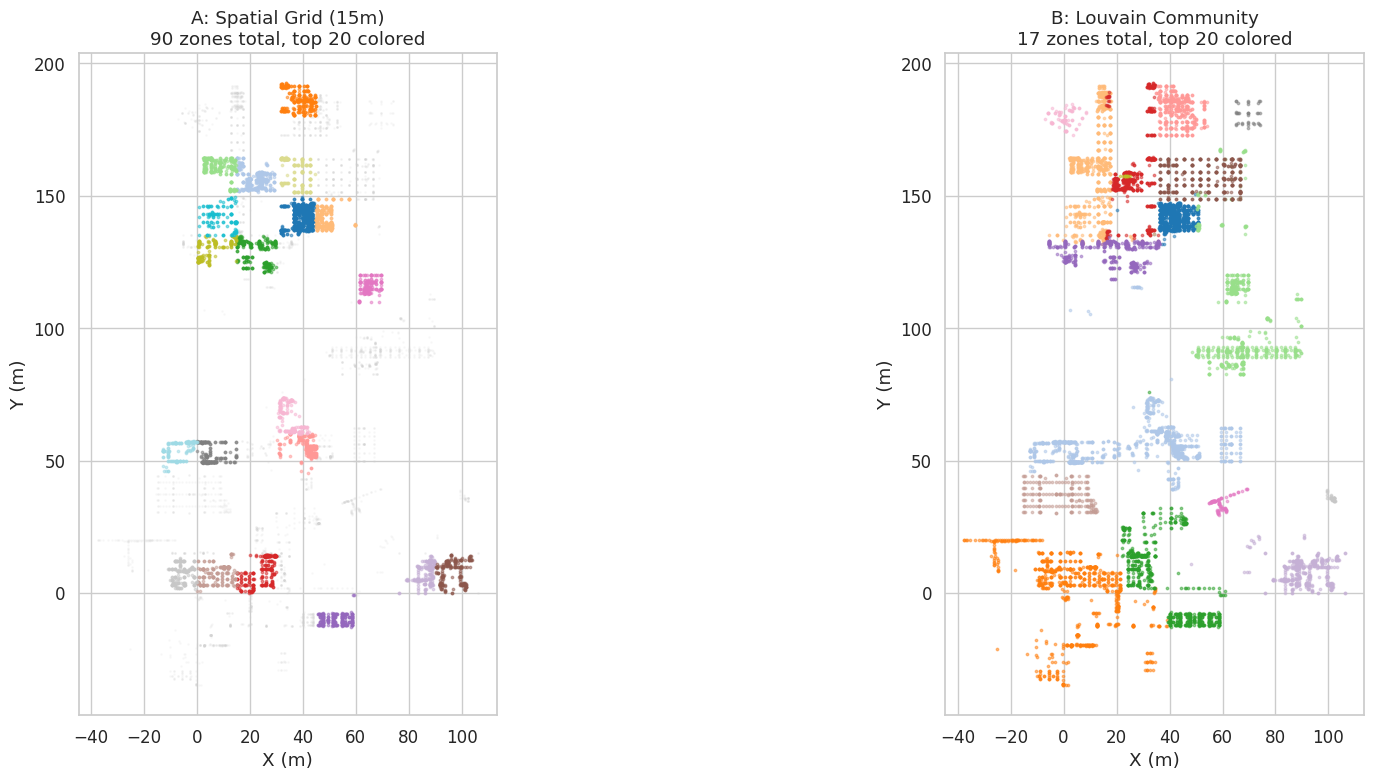

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Color by zone (use top-N zones by size, gray out the rest)
def plot_zones(ax, zone_col, title, n_top=20):
    zone_sizes = phys[zone_col].value_counts()
    top_zones = zone_sizes.head(n_top).index.tolist()
    cmap = plt.cm.tab20
    zone_colors = {z: cmap(i % 20) for i, z in enumerate(top_zones)}
    
    # Background (small zones)
    small = phys[~phys[zone_col].isin(top_zones)]
    ax.scatter(small["centroid_x"], small["centroid_y"], s=1, alpha=0.1, c="lightgray")
    
    # Top zones
    for z in top_zones:
        subset = phys[phys[zone_col] == z]
        ax.scatter(subset["centroid_x"], subset["centroid_y"], 
                   s=3, alpha=0.5, color=zone_colors[z])
    
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_title(f"{title}\n{phys[zone_col].nunique()} zones total, top {n_top} colored")
    ax.set_aspect("equal")

plot_zones(axes[0], "zone_A", f"A: Spatial Grid ({GRID_SIZE}m)")
plot_zones(axes[1], "zone_B", "B: Louvain Community")

plt.tight_layout()
plt.show()

### 2.2 정량 비교 — 4개 CM 지표

| 지표 | 의미 | 좋은 방향 |
|------|------|-----------|
| **교차 간선 비율** | 존 경계를 넘는 adjacency 비율 | 낮을수록 좋음 (존 간 의존성 ↓) |
| **존 크기 균일도** | 존 간 객체 수의 변동계수(CV) | 낮을수록 좋음 (밸런싱 ↑) |
| **존 내 공간 밀집도** | 존 안 객체 간 평균 거리 | 낮을수록 좋음 (자재 이동 ↓) |
| **파이프라인 분산** | 파이프라인 하나가 걸치는 존 수의 평균 | 낮을수록 좋음 (시공 순서 제약 ↓) |

In [5]:
def evaluate_zones(phys_df, adj_df, zone_col, label):
    """Compute 4 CM metrics for a zone assignment."""
    results = {"method": label}
    
    zone_map = dict(zip(phys_df["object_id"], phys_df[zone_col]))
    
    # 1. Cross-zone edge ratio
    cross = 0
    total = 0
    for _, row in adj_df.iterrows():
        s, t = row["source_object_id"], row["target_object_id"]
        if s in zone_map and t in zone_map:
            total += 1
            if zone_map[s] != zone_map[t]:
                cross += 1
    results["cross_edge_ratio"] = cross / total if total > 0 else 0
    results["cross_edges"] = cross
    results["total_edges"] = total
    
    # 2. Zone size uniformity (CV = std / mean, lower is more uniform)
    zone_sizes = phys_df[zone_col].value_counts()
    results["n_zones"] = len(zone_sizes)
    results["size_cv"] = zone_sizes.std() / zone_sizes.mean() if zone_sizes.mean() > 0 else 0
    results["median_zone_size"] = zone_sizes.median()
    results["max_zone_size"] = zone_sizes.max()
    results["min_zone_size"] = zone_sizes.min()
    
    # 3. Intra-zone spatial compactness (mean pairwise distance within zone, sampled)
    np.random.seed(42)
    distances = []
    for zone_id in zone_sizes.head(50).index:  # sample top 50 zones
        members = phys_df[phys_df[zone_col] == zone_id]
        if len(members) < 2:
            continue
        sample = members.sample(min(30, len(members)), random_state=42)
        coords = sample[["centroid_x", "centroid_y", "centroid_z"]].values
        for i in range(len(coords)):
            for j in range(i+1, len(coords)):
                distances.append(np.linalg.norm(coords[i] - coords[j]))
    results["mean_intra_distance_m"] = np.mean(distances) if distances else 0
    
    # 4. Pipeline dispersion (avg zones per pipeline)
    piping_in_zones = phys_df[phys_df["sp3d_pipeline"].notna()][["sp3d_pipeline", zone_col]].copy()
    if len(piping_in_zones) > 0:
        zones_per_pipeline = piping_in_zones.groupby("sp3d_pipeline")[zone_col].nunique()
        results["mean_zones_per_pipeline"] = zones_per_pipeline.mean()
        results["max_zones_per_pipeline"] = zones_per_pipeline.max()
    else:
        results["mean_zones_per_pipeline"] = 0
        results["max_zones_per_pipeline"] = 0
    
    return results

# Run evaluation
result_A = evaluate_zones(phys, adj_phys, "zone_A", f"A: Grid {GRID_SIZE}m")
result_B = evaluate_zones(phys, adj_phys, "zone_B", "B: Louvain")

comparison = pd.DataFrame([result_A, result_B]).set_index("method")
print(comparison.T.to_string())

method                     A: Grid 15m     B: Louvain
cross_edge_ratio              0.443924       0.141166
cross_edges               95536.000000   30380.000000
total_edges              215208.000000  215208.000000
n_zones                      90.000000      17.000000
size_cv                       1.499757       0.791424
median_zone_size             47.000000     490.000000
max_zone_size              1098.000000    1300.000000
min_zone_size                 1.000000      10.000000
mean_intra_distance_m         7.351383      14.734775
mean_zones_per_pipeline       2.000000       1.123288
max_zones_per_pipeline        7.000000       3.000000


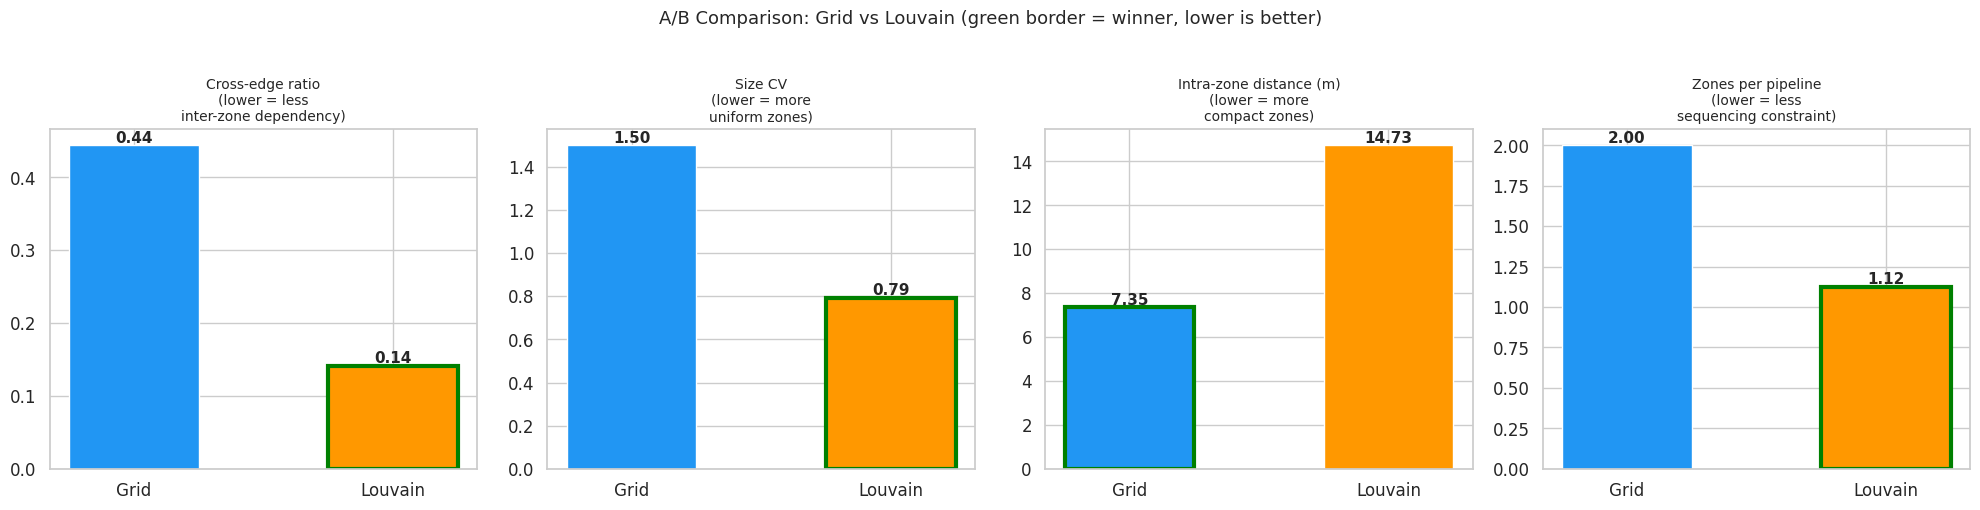


Scoreboard: Grid 1 — Louvain 3 (out of 4 metrics)


In [6]:
# Visual comparison of metrics
metrics = ["cross_edge_ratio", "size_cv", "mean_intra_distance_m", "mean_zones_per_pipeline"]
labels = ["Cross-edge ratio\n(lower = less\ninter-zone dependency)",
          "Size CV\n(lower = more\nuniform zones)",
          "Intra-zone distance (m)\n(lower = more\ncompact zones)", 
          "Zones per pipeline\n(lower = less\nsequencing constraint)"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, metric, label in zip(axes, metrics, labels):
    vals = [result_A[metric], result_B[metric]]
    bars = ax.bar(["Grid", "Louvain"], vals, color=["#2196F3", "#FF9800"], width=0.5)
    ax.set_title(label, fontsize=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    # Highlight winner
    winner = 0 if vals[0] < vals[1] else 1
    bars[winner].set_edgecolor("green")
    bars[winner].set_linewidth(3)

plt.suptitle("A/B Comparison: Grid vs Louvain (green border = winner, lower is better)", 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Scoreboard
a_wins = sum(1 for m in metrics if result_A[m] < result_B[m])
b_wins = sum(1 for m in metrics if result_B[m] < result_A[m])
print(f"\nScoreboard: Grid {a_wins} — Louvain {b_wins} (out of 4 metrics)")

## 3. 파이프라인 교차 분석 — 시공 순서 제약

어떤 파이프라인이 가장 많은 존에 걸치는가? 이 파이프라인이 시공 순서의 **크리티컬 패스**가 됩니다. 어떤 존을 먼저 시공하든, 이 파이프라인은 모든 관련 존이 준비될 때까지 완성할 수 없습니다.

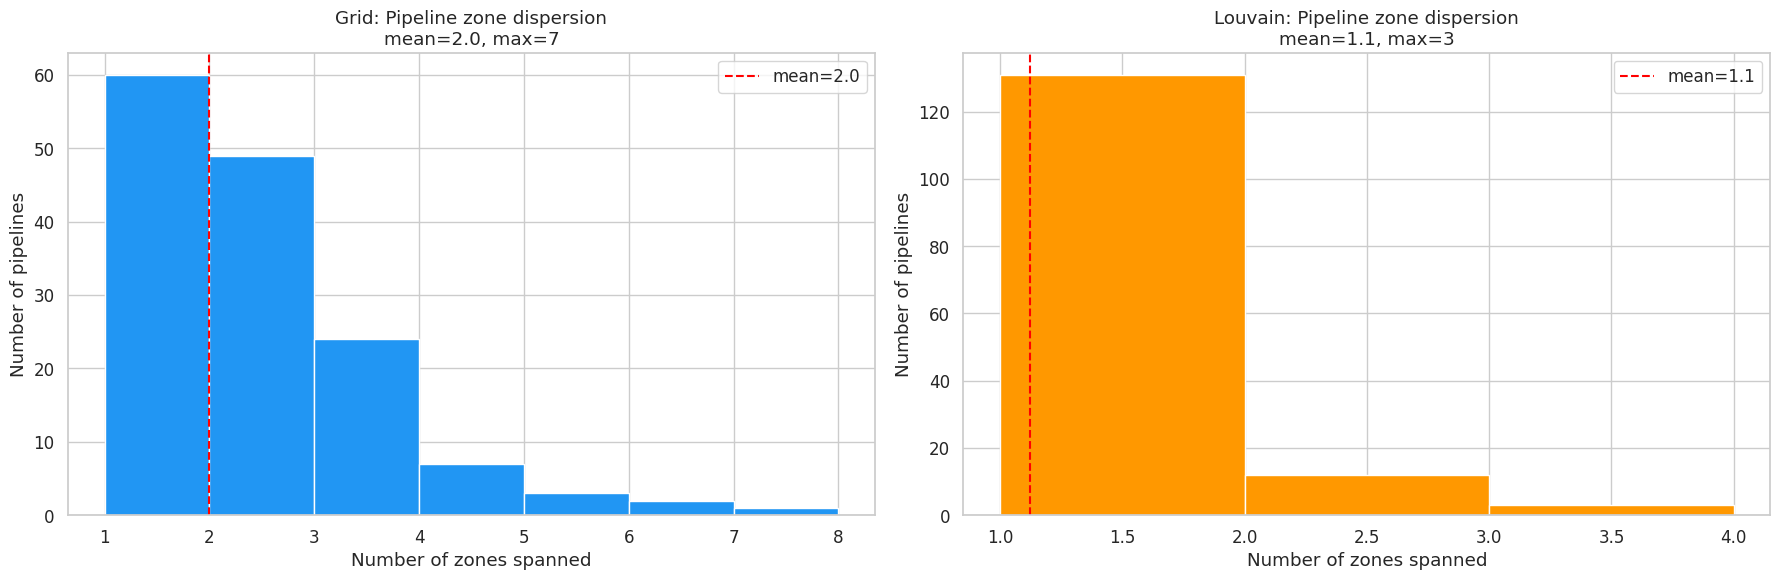

Top 10 most zone-crossing pipelines (Grid method):
  03-PA-2001          :   7 zones,   27 objects
  03-LC-1001          :   6 zones,   33 objects
  03-UA-2001          :   6 zones,   27 objects
  P-10161             :   5 zones,   25 objects
  P-10162             :   5 zones,   43 objects
  400-P               :   5 zones,   82 objects
  03-UW-2001          :   4 zones,   26 objects
  03-BFW-2001         :   4 zones,   18 objects
  03-BFW-2002         :   4 zones,   18 objects
  03-IA-3001          :   4 zones,   21 objects


In [7]:
piping_zones = phys[phys["sp3d_pipeline"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, zone_col, method_label in [
    (axes[0], "zone_A", "Grid"), (axes[1], "zone_B", "Louvain")
]:
    zones_per_pipe = piping_zones.groupby("sp3d_pipeline")[zone_col].nunique().sort_values(ascending=False)
    
    # Distribution
    ax.hist(zones_per_pipe, bins=range(1, zones_per_pipe.max() + 2), 
            edgecolor="white", color="#2196F3" if method_label == "Grid" else "#FF9800")
    ax.set_xlabel("Number of zones spanned")
    ax.set_ylabel("Number of pipelines")
    ax.set_title(f"{method_label}: Pipeline zone dispersion\n"
                 f"mean={zones_per_pipe.mean():.1f}, max={zones_per_pipe.max()}")
    ax.axvline(zones_per_pipe.mean(), color="red", ls="--", label=f"mean={zones_per_pipe.mean():.1f}")
    ax.legend()

plt.tight_layout()
plt.show()

# Top 10 most dispersed pipelines (worst for CM)
print("Top 10 most zone-crossing pipelines (Grid method):")
grid_dispersion = piping_zones.groupby("sp3d_pipeline")["zone_A"].nunique().sort_values(ascending=False)
for pipe, n_zones in grid_dispersion.head(10).items():
    n_obj = len(piping_zones[piping_zones["sp3d_pipeline"] == pipe])
    print(f"  {pipe:20s}: {n_zones:3d} zones, {n_obj:4d} objects")

## 4. 존 내 시공 순서 — Equipment → Structure → Piping

한 존이 정해졌을 때, 존 안���서 뭘 먼저 설치하는가? 일반적인 건설 순서는:
1. **Equipment** (중장비 설치 — 크레인 필요, 공간 확보)
2. **Structure** (철골 프레임 — 장비를 감싸는 구조물)
3. **Piping** (배관 — 구조물 사이를 연결)
4. **Electrical / HVAC** (최종 마감 단계)

이 순서대로 존 별 설치 작업량이 어떻게 분포하는지를 봅니다.

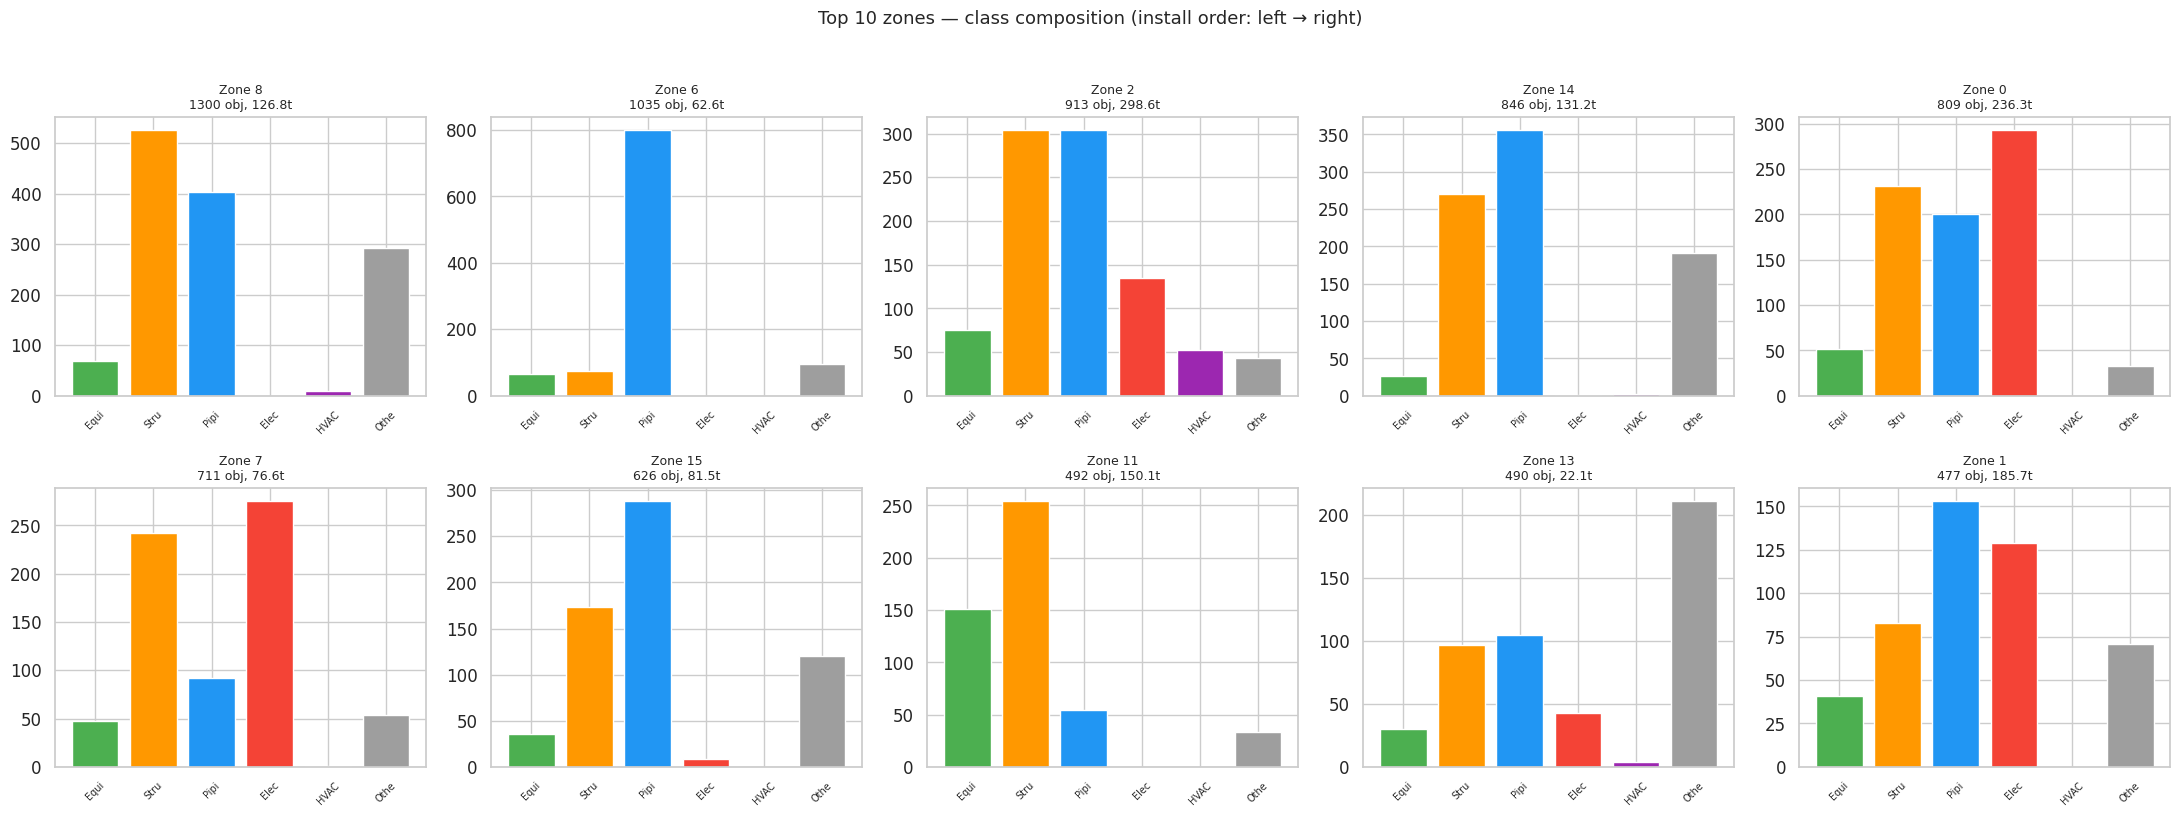

Zones containing equipment: 15 / 17
  → 15 zones need crane planning
  → 2 zones can be built without heavy lifts


In [8]:
# Pick the better-performing zone method for this analysis
# (we'll use both, but focus the narrative on the winner)
zone_col = "zone_B"  # adjust after seeing A/B results above

# Top 10 largest zones
zone_sizes = phys[zone_col].value_counts()
top10_zones = zone_sizes.head(10).index

install_order = ["Equipment", "Structure", "Piping", "Electrical", "HVAC", "Other"]
install_colors = {"Equipment": "#4CAF50", "Structure": "#FF9800", "Piping": "#2196F3",
                  "Electrical": "#F44336", "HVAC": "#9C27B0", "Other": "#9E9E9E"}

fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for idx, zone_id in enumerate(top10_zones):
    ax = axes[idx // 5, idx % 5]
    zone_data = phys[phys[zone_col] == zone_id]
    class_counts = zone_data["refined_class"].value_counts().reindex(install_order).fillna(0)
    
    bars = ax.bar(range(len(install_order)), class_counts.values,
                  color=[install_colors[c] for c in install_order])
    ax.set_xticks(range(len(install_order)))
    ax.set_xticklabels([c[:4] for c in install_order], fontsize=7, rotation=45)
    
    total_weight = zone_data["dry_weight_kg"].sum()
    weight_str = f"{total_weight/1000:.1f}t" if pd.notna(total_weight) else "?"
    ax.set_title(f"Zone {zone_id}\n{len(zone_data)} obj, {weight_str}", fontsize=9)

plt.suptitle("Top 10 zones — class composition (install order: left → right)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary: zones that have equipment (crane needed)
zones_with_equipment = phys[phys["refined_class"] == "Equipment"][zone_col].value_counts()
print(f"Zones containing equipment: {len(zones_with_equipment)} / {len(zone_sizes)}")
print(f"  → {len(zones_with_equipment)} zones need crane planning")
print(f"  → {len(zone_sizes) - len(zones_with_equipment)} zones can be built without heavy lifts")

## 5. 결론과 다음 질문

이 노트북의 결과를 보고 나서 자유롭게 탐색하세요.
- A/B 결과가 한쪽으로 치우쳤다면, **그 방법을 Phase 4 analytics 의 기본으로 채택** 고려
- 비등하다면, **두 방법을 합성** (예: Louvain 으로 나눈 뒤 공간적으로 너무 넓은 존을 split) 하는 C 방법을 시도
- 파이프라인 교차가 심한 존이 보였다면, 그 존의 3D 좌표를 찍어보면 **왜 그런지** ���리적 이유가 보임

In [9]:
# 자유 탐색 공간
